In [40]:
from albumentations import ToTensorV2
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
import os

from utils.dataset import PandasDataset
from utils.metrics import model_checkpoint
from utils.train import train_model
from utils.models import EfficientNetApi

In [28]:
seed = 42
shuffle = True
batch_size = 6
num_workers = 4
output_classes = 5
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
loss_function = nn.BCEWithLogitsLoss()

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

ROOT_DIR = '../../..'

data_dir = '../../../../dataset'
images_dir = os.path.join(data_dir, 'tiles')

Using device: cuda


In [29]:
load_model = efficientnet_b0(
     weights=EfficientNet_B0_Weights.DEFAULT
)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=0.6)
model = model.to(device)

In [30]:
print("Using device:", device)
loss_function = nn.BCEWithLogitsLoss()

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

Using device: cuda


In [31]:
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Registros originais: {len(df_train_)}")

df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")

df_entropy_sorted = df_entropy.sort_values(by="difficulty_score", ascending=False).reset_index(drop=True)

# n_remove = int(len(df_entropy_sorted) * 0.5)
n_remove = 0 #int(len(df_entropy_sorted))
df_entropy_top50 = df_entropy_sorted.head(n_remove)


df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top50['image_id'])].reset_index(drop=True)

print(f"Registros no df_entropy: {len(df_entropy)}")
print(f"Registros no df_entropy_top50: {len(df_entropy_top50)}")
print(f"Registros filtrados (df_train_): {len(df_train_)}")

df_train_.columns = df_train_.columns.str.strip()

# Criar índices de treino e validação
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

# Separar em treino e validação
df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Carregar teste
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

print(f"\nTreino: {len(df_train)} registros")
print(f"Validação: {len(df_val)} registros")
print(f"Teste: {len(df_test)} registros")

Registros originais: 9024
Registros no df_entropy: 903
Registros no df_entropy_top50: 0
Registros filtrados (df_train_): 9024

Treino: 7219 registros
Validação: 1805 registros
Teste: 1592 registros


#### view data

In [32]:
(df_train.shape, df_val.shape, df_test.shape)

((7219, 5), (1805, 5), (1592, 4))

In [33]:
from utils.dataset import RGB2XYZTransform

transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
    # ToTensorV2()
])

valid_transforms = Albu.Compose([
    # RGB2XYZTransform(p=1.0),
    # ToTensorV2()
])

In [34]:
df_train.columns = df_train.columns.str.strip()

train_dataset = PandasDataset(images_dir, df_train, transforms=transforms)
valid_dataset = PandasDataset(images_dir, df_val, transforms=valid_transforms)
test_dataset = PandasDataset(images_dir, df_test, transforms=valid_transforms)

In [35]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, sampler=RandomSampler(train_dataset)
)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=batch_size, num_workers=num_workers, sampler = RandomSampler(valid_dataset)
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, num_workers=num_workers, sampler = RandomSampler(test_dataset)
)

In [36]:
optimizer = optim.Adam(model.parameters(), lr = init_lr / warmup_factor)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(optimizer, multiplier = warmup_factor, total_epoch = warmup_epochs, after_scheduler=scheduler_cosine)

In [37]:
train_model(
    model=model,
    epochs=n_epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    checkpoint=model_checkpoint,
    device=device,
    loss_function=loss_function,
    path_to_save_metrics="logs/b0-entropy-00.txt",
    path_to_save_model="models/b0-entropy-00.pth",
    patience=5,
)

Epoch 1/50



100%|██████████| 301/301 [01:33<00:00,  3.21it/s]


VAL_LOSS     0.286
VAL_ACC      Mean: 51.594 | Std: 1.161 | 95% CI: [49.695, 53.573]
VAL_KAPPA    Mean: 0.776 | Std: 0.011 | 95% CI: [0.758, 0.794]
VAL_F1       Mean: 0.436 | Std: 0.011 | 95% CI: [0.417, 0.455]
VAL_RECALL   Mean: 0.452 | Std: 0.011 | 95% CI: [0.435, 0.470]
VAL_PRECISION Mean: 0.547 | Std: 0.016 | 95% CI: [0.519, 0.572]
Salvando o melhor modelo... 0.0 -> 0.7763138737882592
Epoch 2/50



100%|██████████| 301/301 [01:34<00:00,  3.20it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


VAL_LOSS     0.299
VAL_ACC      Mean: 51.313 | Std: 1.186 | 95% CI: [49.474, 53.302]
VAL_KAPPA    Mean: 0.766 | Std: 0.011 | 95% CI: [0.747, 0.785]
VAL_F1       Mean: 0.440 | Std: 0.012 | 95% CI: [0.420, 0.459]
VAL_RECALL   Mean: 0.449 | Std: 0.011 | 95% CI: [0.431, 0.468]
VAL_PRECISION Mean: 0.550 | Std: 0.013 | 95% CI: [0.529, 0.570]
Epoch 3/50



...

VAL_LOSS     0.536
VAL_ACC      Mean: 60.396 | Std: 1.161 | 95% CI: [58.504, 62.327]
VAL_KAPPA    Mean: 0.809 | Std: 0.013 | 95% CI: [0.786, 0.829]
VAL_F1       Mean: 0.561 | Std: 0.012 | 95% CI: [0.541, 0.582]
VAL_RECALL   Mean: 0.564 | Std: 0.012 | 95% CI: [0.544, 0.584]
VAL_PRECISION Mean: 0.596 | Std: 0.012 | 95% CI: [0.577, 0.616]
Epoch 14/50



100%|██████████| 301/301 [01:33<00:00,  3.22it/s]


VAL_LOSS     0.579
VAL_ACC      Mean: 63.733 | Std: 1.151 | 95% CI: [61.881, 65.651]
VAL_KAPPA    Mean: 0.812 | Std: 0.013 | 95% CI: [0.791, 0.834]
VAL_F1       Mean: 0.571 | Std: 0.013 | 95% CI: [0.551, 0.592]
VAL_RECALL   Mean: 0.565 | Std: 0.012 | 95% CI: [0.546, 0.585]
VAL_PRECISION Mean: 0.597 | Std: 0.013 | 95% CI: [0.575, 0.619]
Epoch 15/50



100%|██████████| 301/301 [01:29<00:00,  3.35it/s]


VAL_LOSS     0.575
VAL_ACC      Mean: 62.538 | Std: 1.174 | 95% CI: [60.609, 64.598]
VAL_KAPPA    Mean: 0.810 | Std: 0.013 | 95% CI: [0.789, 0.832]
VAL_F1       Mean: 0.554 | Std: 0.013 | 95% CI: [0.533, 0.577]
VAL_RECALL   Mean: 0.550 | Std: 0.012 | 95% CI: [0.531, 0.571]
VAL_PRECISION Mean: 0.588 | Std: 0.013 | 95% CI: [0.566, 0.610]

Early stopping at epoch 15. No improvement for 5 epochs.
Best epoch: 10 with kappa: 0.8268


# tests

In [38]:
from utils.metrics import evaluation, format_metrics
model.load_state_dict(
    torch.load(f"models/b0-entropy-00.pth")
)
response = evaluation(model, test_loader, device)
result = format_metrics(response[0])
print(result)

100%|██████████| 266/266 [01:10<00:00,  3.75it/s]


VAL_ACC      Mean: 61.476 | Std: 1.199 | 95% CI: [59.485, 63.442]
VAL_KAPPA    Mean: 0.840 | Std: 0.012 | 95% CI: [0.819, 0.859]
VAL_F1       Mean: 0.561 | Std: 0.013 | 95% CI: [0.540, 0.582]
VAL_RECALL   Mean: 0.560 | Std: 0.013 | 95% CI: [0.539, 0.581]
VAL_PRECISION Mean: 0.584 | Std: 0.013 | 95% CI: [0.563, 0.604]


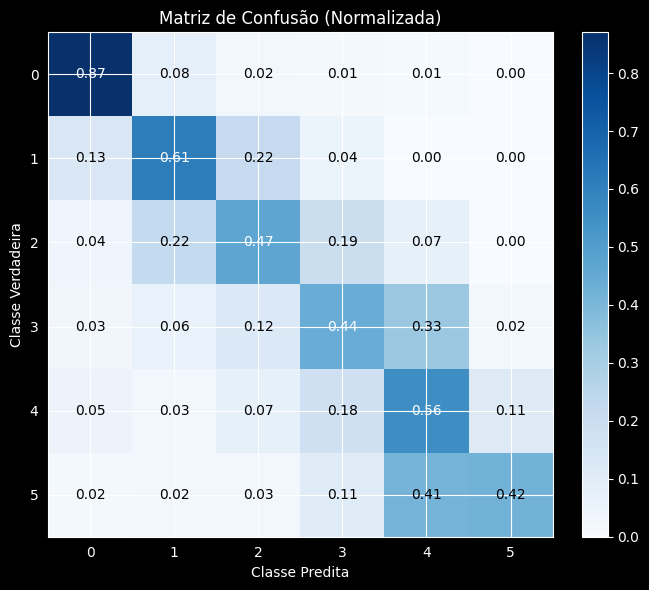

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# sua matriz (exemplo)
cm = np.array(response[0].get("confusion_matrix"))

classes = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(8, 6))
im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Matriz de Confusão (Normalizada)")
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Predita")

# adicionar valores nas células
fmt = ".2f"
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()
